<a href="https://colab.research.google.com/github/iamnaymur/ml_meta_learning/blob/main/week_02_getting_started_ml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
print("hello world")

hello world


# Getting_started_with_ML

## Exploratro Data Analysis (EDA)

### Setup and Data Loading

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")
sns.set(font_scale=1.1)

# from google.colab import files

from google.colab import drive
drive.mount('/content/drive')


# upload heart.cs from your computer
uploaded = '/content/drive/MyDrive/Machine learning/heart.csv'

# the kaggle file is named "heart.csv"
df = pd.read_csv(uploaded)

df.head(10)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
5,39,M,NAP,120,339,0,Normal,170,N,0.0,Up,0
6,45,F,ATA,130,237,0,Normal,170,N,0.0,Up,0
7,54,M,ATA,110,208,0,Normal,142,N,0.0,Up,0
8,37,M,ASY,140,207,0,Normal,130,Y,1.5,Flat,1
9,48,F,ATA,120,284,0,Normal,120,N,0.0,Up,0


In [ ]:
# basic info about rowns, columns and data types
print(df.shape)
# with info which column is which datatype, and the non null count
print("info :")
df.info()

(918, 12)
info :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [ ]:
# quick descriptive statistics for numeric columns
# like seeing mean, std,max , count etc with descrive
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,918.0,53.510893,9.432617,28.0,47.00,54.0,60.0,77.0
RestingBP,918.0,132.396514,18.514154,0.0,120.00,130.0,140.0,200.0
Cholesterol,918.0,198.799564,109.384145,0.0,173.25,223.0,267.0,603.0
FastingBS,918.0,0.233115,0.423046,0.0,0.00,0.0,0.0,1.0
MaxHR,918.0,136.809368,25.460334,60.0,120.00,138.0,156.0,202.0
Oldpeak,918.0,0.887364,1.066570,-2.6,0.00,0.6,1.5,6.2
HeartDisease,918.0,0.553377,0.497414,0.0,0.00,1.0,1.0,1.0


In [ ]:
# define target and feature types
target_col = "HeartDisease"
numeric_cols = ["Age", "RestingBP", "Cholesterol", "FastingBS", "MaxHR", "Oldpeak"]
categorical_cols = ["Sex", "ChestPainType", "RestingECG", "ExerciseAngina", "ST_Slope"]

print(target_col)
print(numeric_cols)
print(categorical_cols)

HeartDisease
['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak']
['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']


### Missing Values and basic quality check

In [ ]:
# check missing values count per column
#  this is where the EDA actually starts from !!!!

df.isna().sum()
# only for numeric_cols cause min max and the others cant be find with no numeric data columns
df[numeric_cols].agg(["min", "max", "mean", "median"]).T
# if the mean and median is close the data is almost symmetric
# mean > median , possible right skew
# mean < median, left skewed data
#  so much gap between these two indicates extreme outliers


,min,max,mean,median
Age,28.0,77.0,53.510893,54.0
RestingBP,0.0,200.0,132.396514,130.0
Cholesterol,0.0,603.0,198.799564,223.0
FastingBS,0.0,1.0,0.233115,0.0
MaxHR,60.0,202.0,136.809368,138.0
Oldpeak,-2.6,6.2,0.887364,0.6


In [ ]:
# categorical column gula unique value dekhbo
#  like the gender columns just containst m and f
# this is important cause suppose the input for male someone put is "_male", so we could see it in the output and take actions
for c in categorical_cols:
  print(c, df[c].unique())

Sex ['M' 'F']
ChestPainType ['ATA' 'NAP' 'ASY' 'TA']
RestingECG ['Normal' 'ST' 'LVH']
ExerciseAngina ['N' 'Y']
ST_Slope ['Up' 'Flat' 'Down']


### Understanding Distributions with Histograms and Boxplots

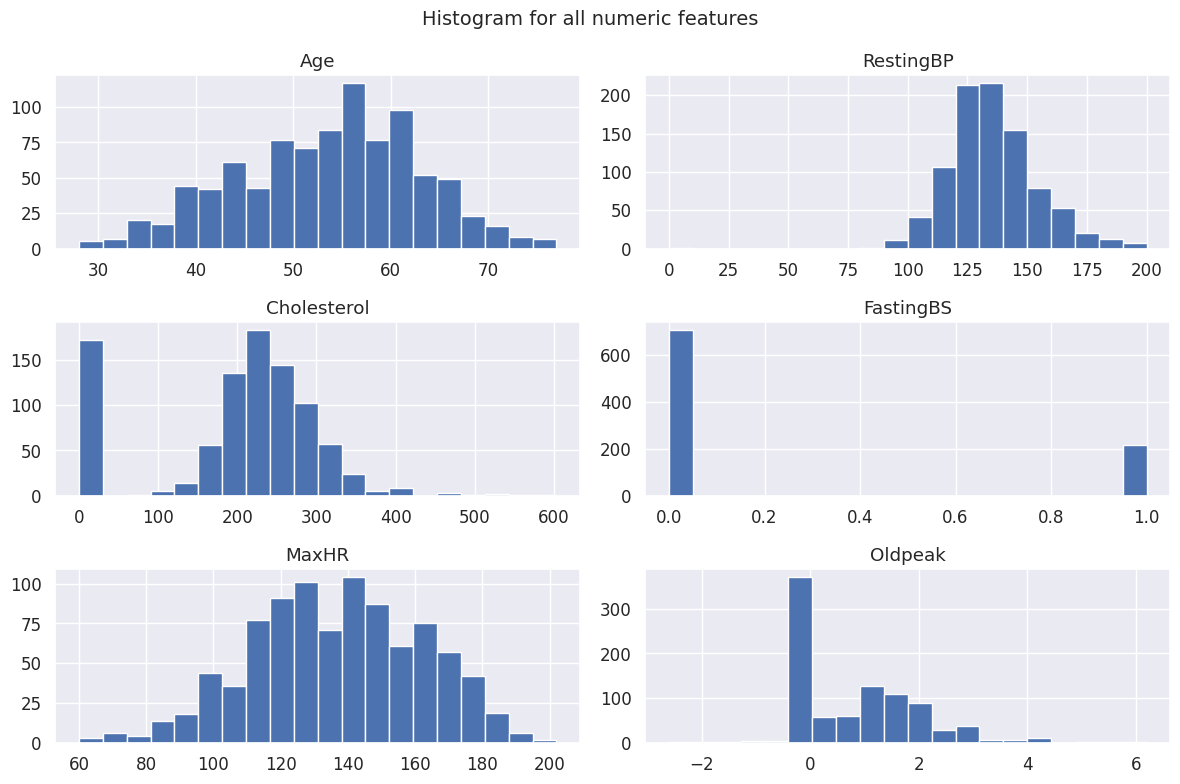

In [ ]:
# Histogram for features, for visualizing
df[numeric_cols].hist(bins= 20, figsize=(12, 8))
plt.suptitle("Histogram for all numeric features", fontsize = 14)
plt.tight_layout()
plt.show()


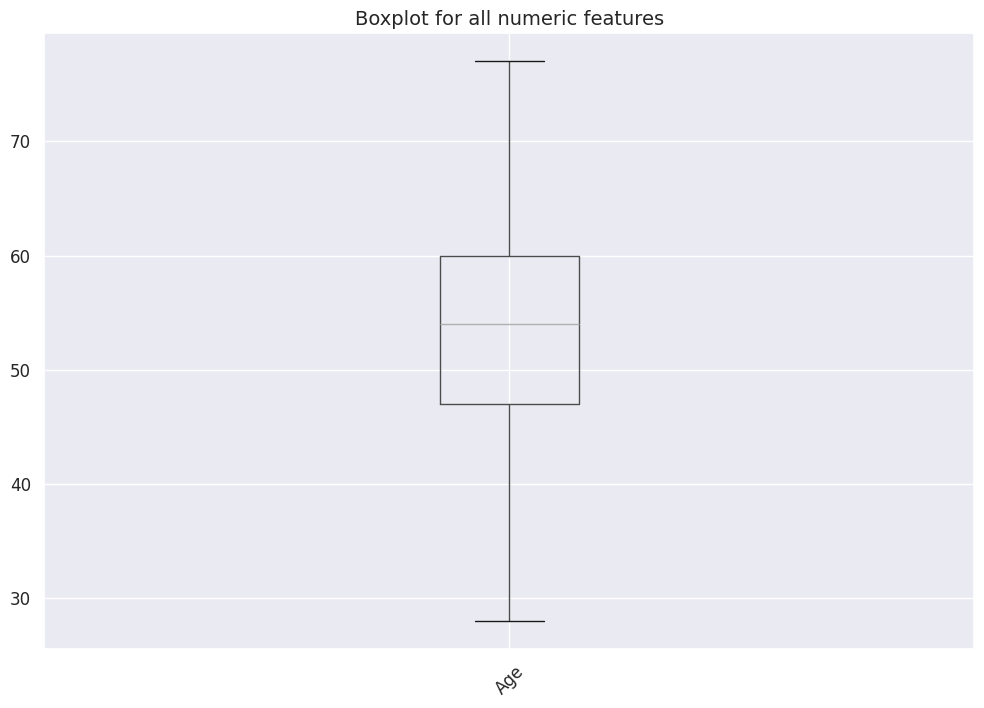

In [ ]:
# for a single feature with boxplot
plt.figure(figsize=(12, 8))
df.boxplot(column =numeric_cols[0]) #here [0] represents the column age
plt.title("Boxplot for all numeric features", fontsize = 14)
plt.xticks(rotation = 45)
plt.show()

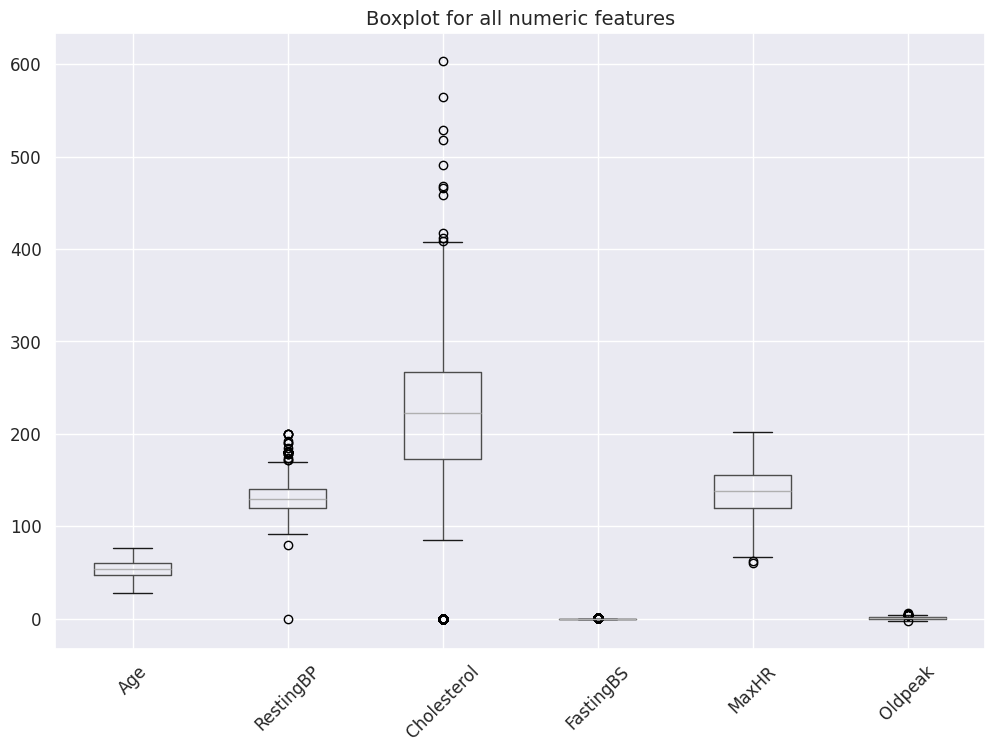

In [ ]:
# Boxplot to get a sense of spread and possible outliers for numeric cols
plt.figure(figsize=(12, 8))
df[numeric_cols].boxplot()
plt.title("Boxplot for all numeric features", fontsize = 14)
plt.xticks(rotation = 45)
plt.show()

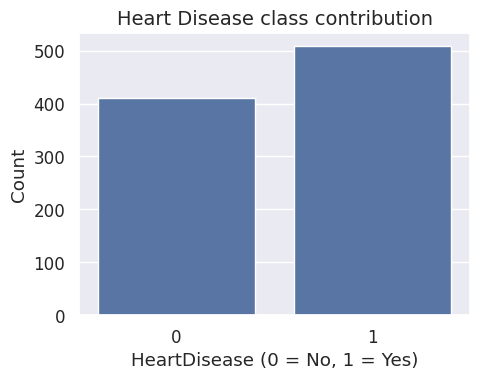

,proportion
HeartDisease,
1,0.553377
0,0.446623


In [ ]:
# Target distribution and class imbalance with seaborn
plt.figure(figsize = (5, 4))
sns.countplot(x = df[target_col])
plt.title("Heart Disease class contribution", fontsize = 14)
plt.xlabel("HeartDisease (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# this line below with value_counts says that 44% is for 0 and the rest is for 1
df[target_col].value_counts(normalize = True)

### Categorical Feature exploration

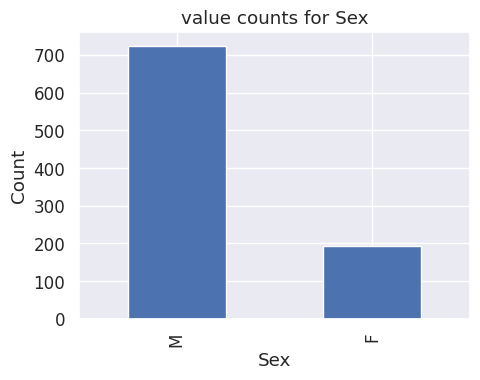

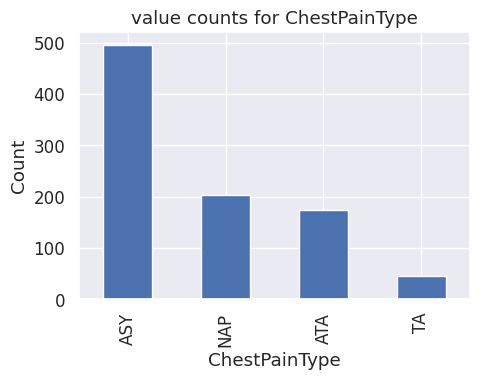

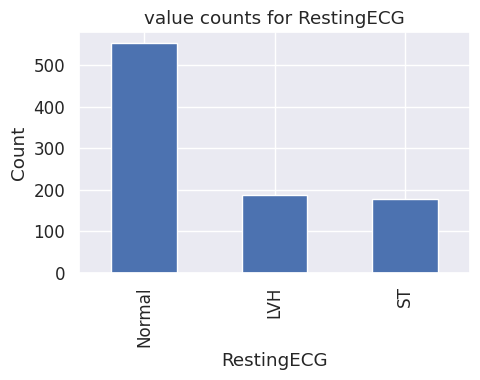

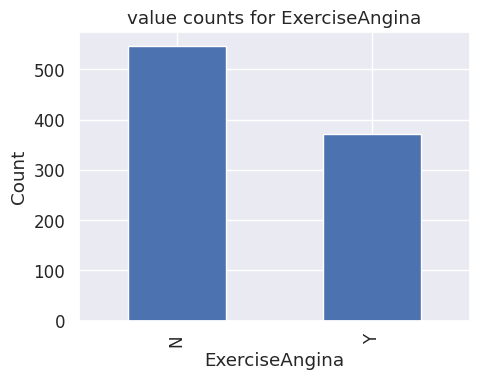

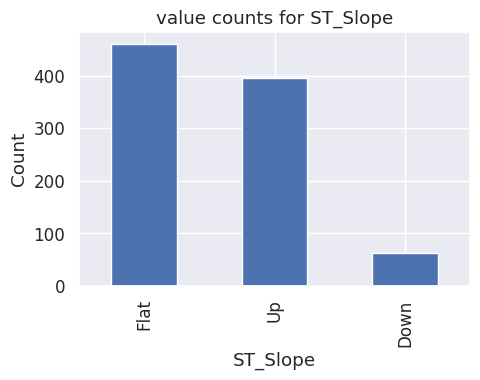

In [ ]:
# categorical feature exploration
# This code below Shows the distribution/count of each category in every categorical feature
for c in categorical_cols:
  plt.figure(figsize = (5, 4))
  df[c].value_counts().plot(kind= "bar")
  plt.title(f"value counts for {c}")
  plt.ylabel("Count")
  plt.tight_layout()
  plt.show()

### Ralationsships between Features and Target

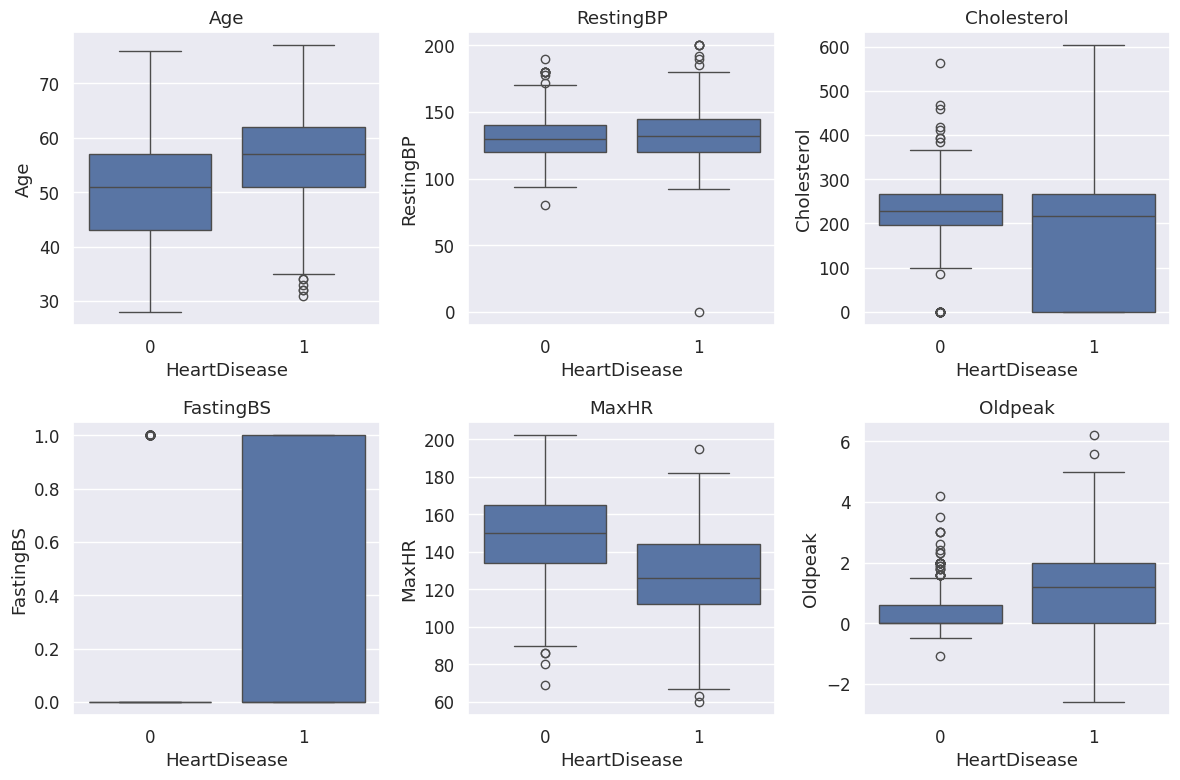

In [ ]:
# we will visualize each features against the target and then look at correlations
# boxplots of numeric features split by heartDisease
plt.figure(figsize = (12, 8))
for i, col in enumerate(numeric_cols, 1):
  plt.subplot(2, 3, i)
  sns.boxplot(x = df[target_col], y = df[col])
  plt.title(col)

plt.tight_layout()
plt.show()

# Compare each numeric feature between the target classes using boxplots
# Example: compare Age distribution between people with and without heart disease

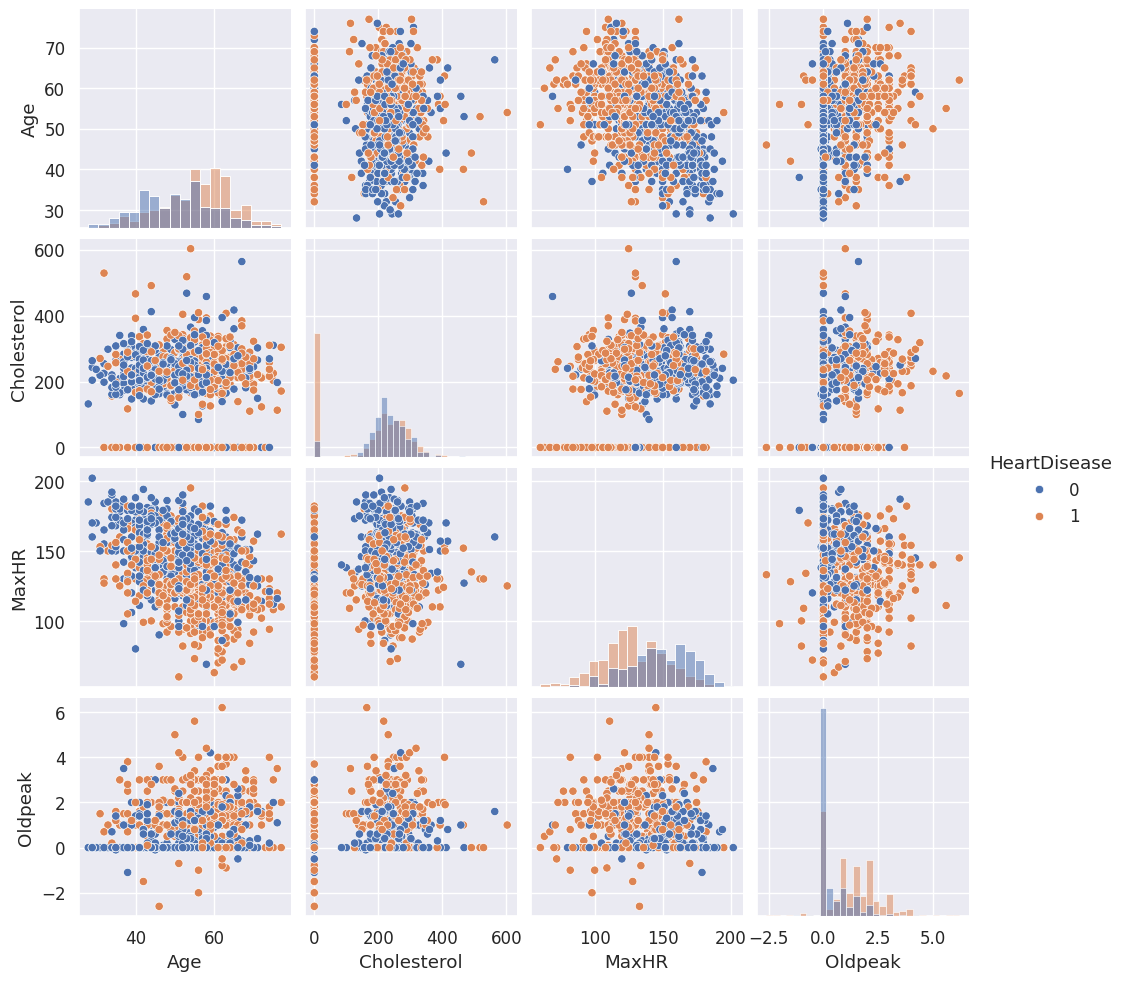

In [ ]:
# pairplot for  a subset of features
sns.pairplot(df[["Age", "Cholesterol", "MaxHR", "Oldpeak", "HeartDisease"]], hue = "HeartDisease", diag_kind="hist")
plt.show()

# A scatter plot shows the relationship between two numerical variables.

# Pairplot shows relationships between multiple features at once
# hue separates the data based on the target (HeartDisease)
# Example: see whether Age, Cholesterol, MaxHR, and Oldpeak differ between HeartDisease = 0 and 1

### Correlation Matrix and heatmap

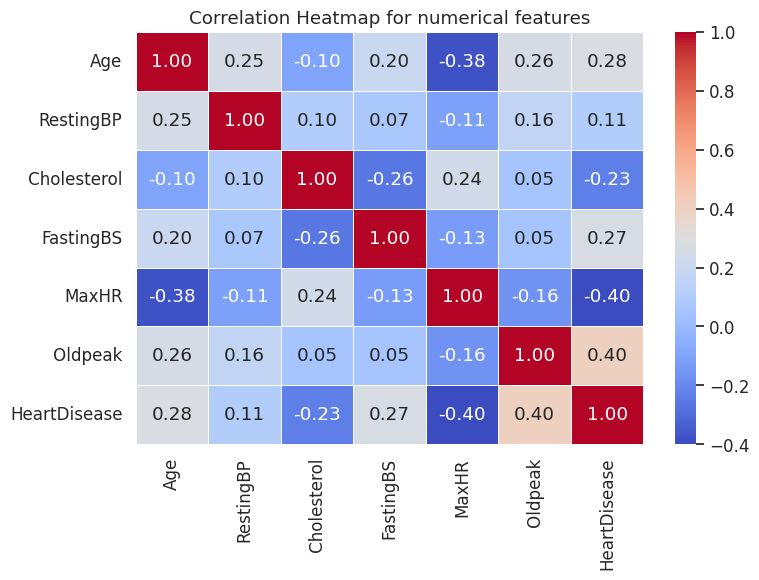

In [ ]:
# correlation er jonno only numeric gula nibo, ar categorical gula use kkorte chaile convert / encoded koira nite hobe


# Correlation ranges from -1 to +1:
# +1 = perfect positive relationship, 0 = no linear relationship, -1 = perfect negative relationship.
# The closer the value is to +1 or -1, the stronger the linear relationship.
# Positive → both tend to increase together; Negative → one tends to increase as the other decreases.
# Correlation shows association, not causation.


corr_matrix = df[numeric_cols + [target_col]].corr()
plt.figure(figsize = (8, 6))
sns.heatmap(corr_matrix, annot = True, cmap= "coolwarm", fmt =".2f" ,  linewidths = 0.5)
plt.title("Correlation Heatmap for numerical features")
plt.tight_layout()
plt.show()

# Red / Dark Red → Strong positive correlation (both increase together)
# Blue / Dark Blue → Strong negative correlation (one increases, the other decreases)
# White / Light colors → Weak or almost no correlation

In [ ]:
# target variable er sathe onnanno features er correlation
# 2 ta feature er moddhe correlation high kina, and oi 2 ta feature same contribution kortese kina target variable ke, taile ekta exclude kora jay
corr_matrix[target_col].sort_values(ascending = False)

,HeartDisease
HeartDisease,1.000000
Oldpeak,0.403951
Age,0.282039
FastingBS,0.267291
RestingBP,0.107589
Cholesterol,-0.232741
MaxHR,-0.400421


### Categorical features vs target



Proportion of HeartDiseases withing Sex


HeartDisease,0,1
Sex,,
F,0.740933,0.259067
M,0.368276,0.631724


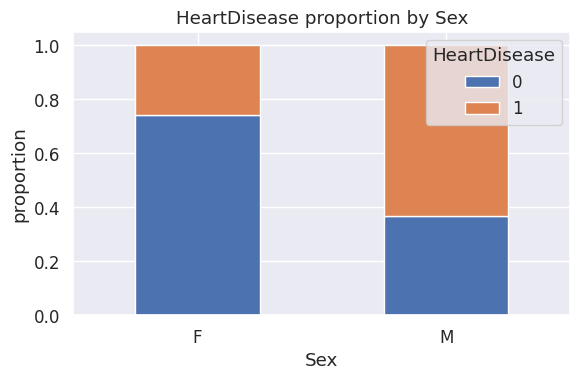


Proportion of HeartDiseases withing ChestPainType


HeartDisease,0,1
ChestPainType,,
ASY,0.209677,0.790323
ATA,0.861272,0.138728
NAP,0.645320,0.354680
TA,0.565217,0.434783


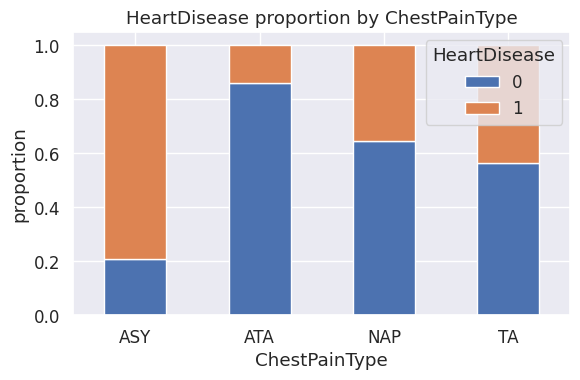


Proportion of HeartDiseases withing RestingECG


HeartDisease,0,1
RestingECG,,
LVH,0.436170,0.563830
Normal,0.483696,0.516304
ST,0.342697,0.657303


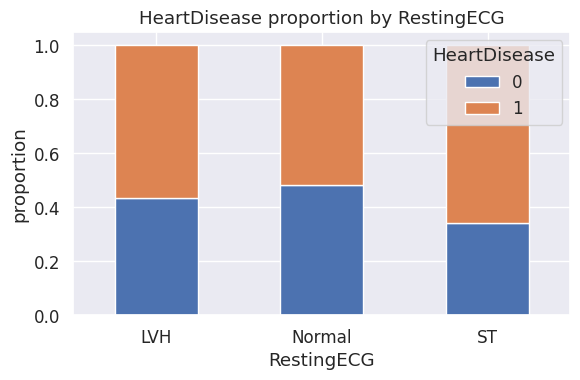


Proportion of HeartDiseases withing ExerciseAngina


HeartDisease,0,1
ExerciseAngina,,
N,0.648995,0.351005
Y,0.148248,0.851752


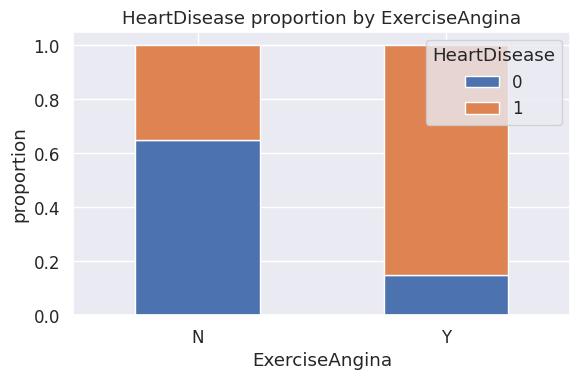


Proportion of HeartDiseases withing ST_Slope


HeartDisease,0,1
ST_Slope,,
Down,0.222222,0.777778
Flat,0.171739,0.828261
Up,0.802532,0.197468


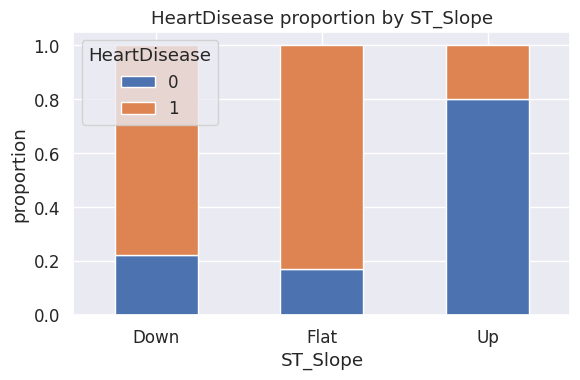

In [ ]:
# pd.crosstab() counts how the categories of c are distributed across the target
# this is the barchart part
# normalize="index" changes the counts into proportions within each category

for c in categorical_cols:
  cross_table = pd.crosstab(df[c], df[target_col], normalize="index")
  print(f"\nProportion of HeartDiseases withing {c}")
  display(cross_table)

  cross_table.plot(kind = "bar", stacked = True, figsize =(6, 4))
  plt.title(f"HeartDisease proportion by {c}")
  plt.ylabel("proportion")
  plt.xticks(rotation = 0)
  plt.tight_layout()
  plt.show()

## Data preprocessing and feature engineering

### Handling missing values part 1 (Titani Dataset)

In [ ]:
"""
From the dataset we have already seen that
Age column has missing values
and Embarked and Cabin

So fill the values up, we will
Fill numeric column (Age) with the median
Categorical column (Embarked) with the mode
Drop (Cabin) because it is mostly missing
"""

import pandas as pd

titanic_path = "/content/drive/MyDrive/Machine learning/Titanic-Dataset.csv"
df_titanic = pd.read_csv(titanic_path)

print("first 10 rows of the titanic dataset")
df_titanic.head(10)

first 10 rows of the titanic dataset


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [ ]:
# df_titanic.shape
print("Unique values per column")
# suppose for the column surived it is 1 or 0, 1 = Lived, 0 = Dead
# so the nunique count for survived will be 2
df_titanic.nunique()

Unique values per column


,0
PassengerId,891
Survived,2
Pclass,3
Name,891
Sex,2
Age,88
SibSp,7
Parch,7
Ticket,681
Fare,248


In [ ]:
print("Missing value per column")
df_titanic.isnull().sum()

"""
if any feature has 70% value missing, then skipping the feature is better idea

Age has 177 missing values

Cabin has 687 missing values -> total row is 891 and cabin has 687 missing, taile cabin raikha ar lav nai. Lets just drop this feature

Embarked has 2 missing values
"""



Missing value per column


'\nif any feature has 70% value missing, then skipping the feature is better idea\n\nAge has 177 missing values\n\nCabin has 687 missing values -> total row is 891 and cabin has 687 missing, taile cabin raikha ar lav nai. Lets just drop this feature\n\nEmbarked has 2 missing values\n'

Distribution of age column


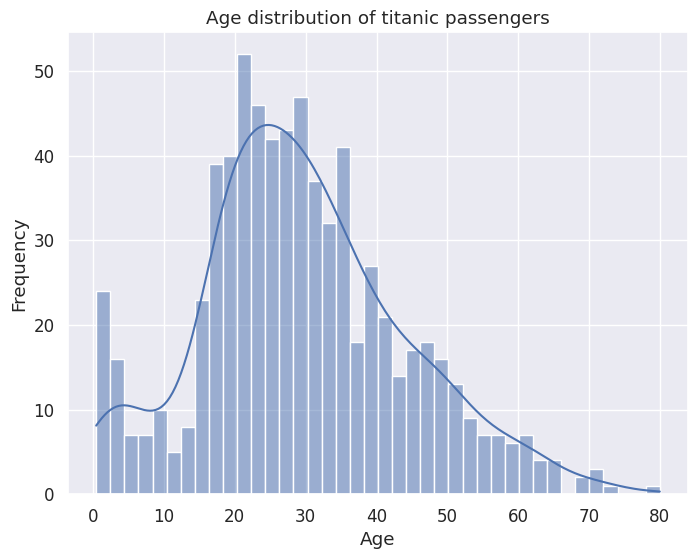

In [ ]:
print("Distribution of age column")
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize =(8, 6))
# kde puts the line on above the bars
# bin = max bars you want in the output, as the total data rows ar almost 900, so the max value for bins can be 900, the total rown size
sns.histplot(df_titanic["Age"], kde = True, bins = 40)
plt.title("Age distribution of titanic passengers")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

# we will use median as the fature values are right skewed

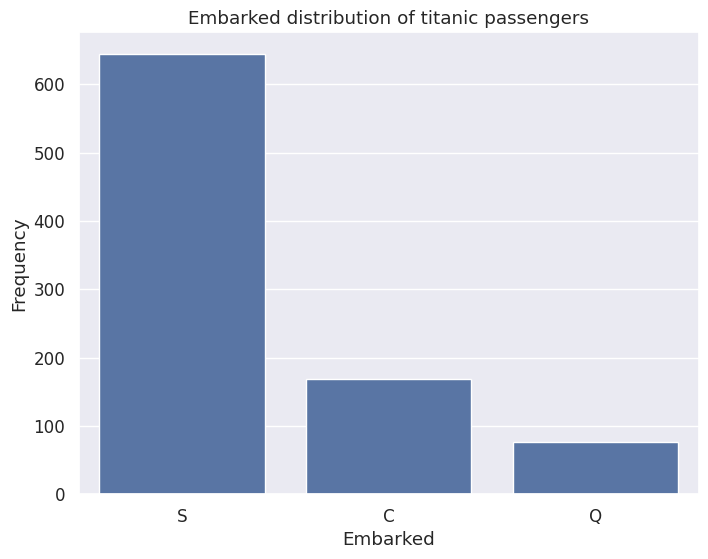

In [ ]:
plt.figure(figsize =(8, 6))
sns.countplot(data = df_titanic, x = "Embarked")
plt.title("Embarked distribution of titanic passengers")
plt.xlabel("Embarked")
plt.ylabel("Frequency")
plt.show()

#  as the missing embarked data count is only 2 and the maximum people used the s port, so we can assume that the missing 2 people also catchecd the ship from there, so we will use the mode [maximum frequency value]

In [ ]:
# 1. Fill the age missing value
age_median = df_titanic["Age"].median()
# age_median
df_titanic["Age"]=df_titanic["Age"].fillna(age_median)

# 2. Fill the embarked missing value
embarked_mode = df_titanic["Embarked"].mode()[0]
# embarked_mode
df_titanic["Embarked"] = df_titanic["Embarked"].fillna(embarked_mode)

# 3. drop the colum cabin
df_titanic = df_titanic.drop(columns = ["Cabin"])

# df_titanic.shape

In [ ]:
print("Missing values after handling")
df_titanic.isnull().sum()

Missing values after handling


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


### Encoding Categorical Variables (with heart disease dataset)

---



In [ ]:
from sklearn.preprocessing import LabelEncoder

heart_path = "/content/drive/MyDrive/Machine learning/heart.csv"
df_heart = pd.read_csv(heart_path)

print("First 10 rows of heart disease dataset:")
display(df_heart.head(10))

print("\nColumn data types :")
display(df_heart.dtypes)

First 10 rows of heart disease dataset:


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
5,39,M,NAP,120,339,0,Normal,170,N,0.0,Up,0
6,45,F,ATA,130,237,0,Normal,170,N,0.0,Up,0
7,54,M,ATA,110,208,0,Normal,142,N,0.0,Up,0
8,37,M,ASY,140,207,0,Normal,130,Y,1.5,Flat,1
9,48,F,ATA,120,284,0,Normal,120,N,0.0,Up,0



Column data types :


,0
Age,int64
Sex,object
ChestPainType,object
RestingBP,int64
Cholesterol,int64
FastingBS,int64
RestingECG,object
MaxHR,int64
ExerciseAngina,object
Oldpeak,float64


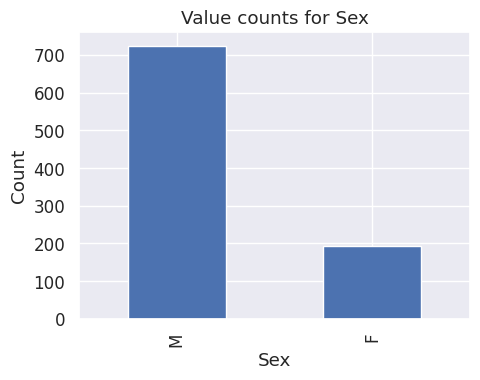

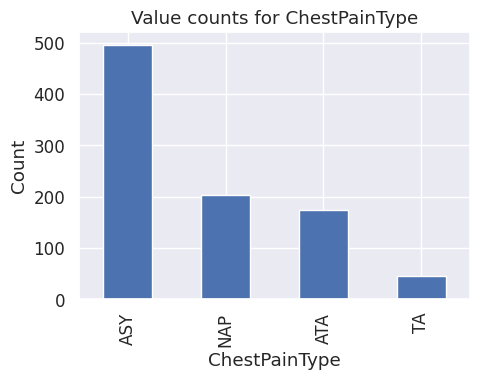

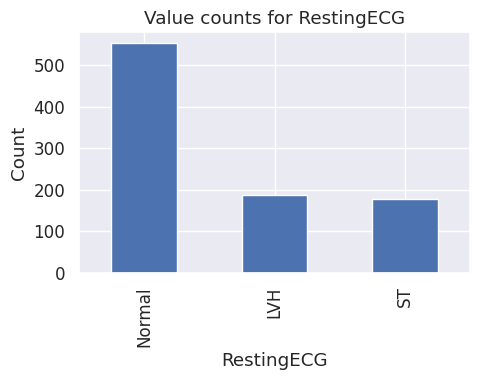

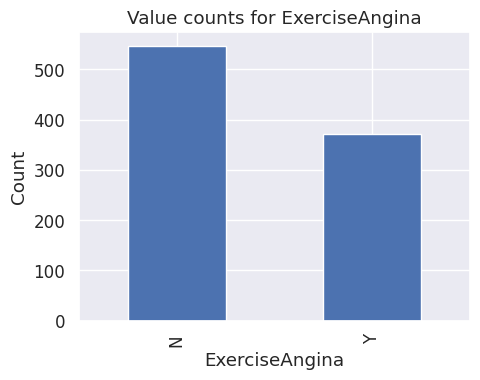

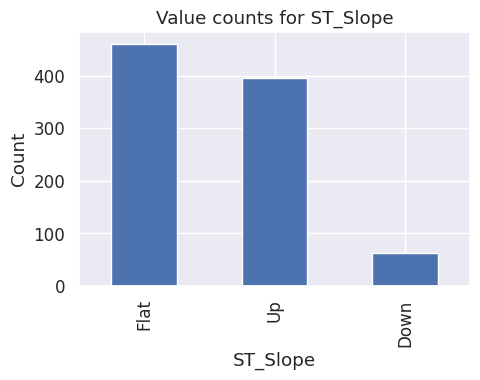

In [ ]:
# categorical feature exploration

"""
dekhtesi je kon feature e  koyta category ase
suppose sex  -> male and female only. taile eitare encoding amra sudhu 0 and 1 diyai kore felte pari
eivabe bakigular jonnow decision neyar jonnoi ei feature exploaration part ta

jehetu sex and exerciseEngina te 2 tai category ase only
tai ei 2 tare amra binary or label encoding korte pari with 0 and 1

and for the other two we could use one hot encoding, for chestpainttype and st_slope
"""
categorical_cols_heart_disease = ["Sex", "ChestPainType", "RestingECG", "ExerciseAngina", "ST_Slope"]

for c in categorical_cols_heart_disease:
  plt.figure(figsize=(5, 4))
  df_heart[c].value_counts().plot(kind = "bar")
  plt.title(f"Value counts for {c}")
  plt.ylabel("Count")
  plt.tight_layout()
  plt.show()

In [ ]:
# Label encoding for binary categorical colums -> sex and exerciseAngina
# replacing sex and excerciseAngian with 0 and 1
le = LabelEncoder()
df_heart["Sex"] = le.fit_transform(df_heart["Sex"])
df_heart["ExerciseAngina"] = le.fit_transform(df_heart["ExerciseAngina"])

df_heart.head(10)


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,1,ATA,140,289,0,Normal,172,0,0.0,Up,0
1,49,0,NAP,160,180,0,Normal,156,0,1.0,Flat,1
2,37,1,ATA,130,283,0,ST,98,0,0.0,Up,0
3,48,0,ASY,138,214,0,Normal,108,1,1.5,Flat,1
4,54,1,NAP,150,195,0,Normal,122,0,0.0,Up,0
5,39,1,NAP,120,339,0,Normal,170,0,0.0,Up,0
6,45,0,ATA,130,237,0,Normal,170,0,0.0,Up,0
7,54,1,ATA,110,208,0,Normal,142,0,0.0,Up,0
8,37,1,ASY,140,207,0,Normal,130,1,1.5,Flat,1
9,48,0,ATA,120,284,0,Normal,120,0,0.0,Up,0


In [ ]:
# Onehot encoding for nominal categorical columns
cat_cols_heart_disease = ["ChestPainType", "RestingECG", "ST_Slope"]
df_heart_encoded = pd.get_dummies(
    df_heart,
    columns = cat_cols_heart_disease,
    dtype = int
)

# now we can see the new columns added in the table
df_heart_encoded.head(10)

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,HeartDisease,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,40,1,140,289,0,172,0,0.0,0,0,1,0,0,0,1,0,0,0,1
1,49,0,160,180,0,156,0,1.0,1,0,0,1,0,0,1,0,0,1,0
2,37,1,130,283,0,98,0,0.0,0,0,1,0,0,0,0,1,0,0,1
3,48,0,138,214,0,108,1,1.5,1,1,0,0,0,0,1,0,0,1,0
4,54,1,150,195,0,122,0,0.0,0,0,0,1,0,0,1,0,0,0,1
5,39,1,120,339,0,170,0,0.0,0,0,0,1,0,0,1,0,0,0,1
6,45,0,130,237,0,170,0,0.0,0,0,1,0,0,0,1,0,0,0,1
7,54,1,110,208,0,142,0,0.0,0,0,1,0,0,0,1,0,0,0,1
8,37,1,140,207,0,130,1,1.5,1,1,0,0,0,0,1,0,0,1,0
9,48,0,120,284,0,120,0,0.0,0,0,1,0,0,0,1,0,0,0,1


### Normalization and Scaling part 1

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
"""
to imply more than one scaling method for one dataset we have to take some other precausions which we didnt learn yet

so in here below, we will only use one scaling
"""

# df_heart_encoded
target_col_heart = "HeartDisease"
# x holds every feature just not the target col
X = df_heart_encoded.drop(columns= [target_col_heart])

Y = df_heart_encoded[target_col_heart]
"""
x_trains is the features used to train the model
X_test -> used to test the model
Y_train -> used to train the model
Y_test -> used to test the model
test_size = 0.25 -> 25% goes to testing and 75% goes for training
"""
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.25, random_state=42)


# standard scaling starts ---------
scaler_sd = StandardScaler()

# fit_transform is used because it calculates the mean and sd deviation from x_train and then uses those values to standardize x_train

X_train_std = scaler_sd.fit_transform(X_train) #mean and sd will be calculated from X_train

# below we just use transform , cause we have already callculated mean and sd above and this prevents the data leakage
X_test_std = scaler_sd.transform(X_test)
# standard scaling ends ---------

# minMax Scaling starts ---------
scaler_mm = MinMaxScaler()
X_train_mm = scaler_mm.fit_transform(X_train)
X_test_mm = scaler_mm.transform(X_test)
# minMax Scaling ends ---------


print("\n---- Displaying Standard scaled Data ---")

# Converyt scaled arrays back to dataframe for better visualization with column names
# We convert the scaled NumPy array back into a DataFrame so it's easier to read and work with.
# Displaying for standard scaling
X_train_std_df = pd.DataFrame(X_train_std, columns= X_train.columns, index = X_train.index)
X_test_std_df = pd.DataFrame(X_test_std, columns= X_test.columns, index = X_test.index)

# print("\nFirst 5 rows of X_train (Standard scaled):")
# display(X_train_std_df.head(5))
# print("\nTest table below")
# display(X_test_std_df.head(5))

# Displaying for minmax scaling

X_train_mm_df = pd.DataFrame(X_train_mm, columns= X_train.columns, index = X_train.index)
X_test_mm_df = pd.DataFrame(X_test_mm, columns= X_test.columns, index = X_test.index)

# sob gulo data points ke 0 and 1 er vitor niya ashe minmax scaling
print("\nFirst 5 rows of X_train (MinMax):")
display(X_train_mm_df.head(5))
print("\nTest table below")
display(X_test_mm_df.head(5))




---- Displaying Standard scaled Data ---

First 5 rows of X_train (MinMax):


,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
155,0.562500,1.0,0.775,0.567164,1.0,0.674419,1.0,0.636364,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
362,0.562500,1.0,0.775,0.000000,0.0,0.279070,0.0,0.295455,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
869,0.625000,1.0,0.750,0.351575,1.0,0.728682,0.0,0.477273,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
101,0.458333,1.0,0.650,0.296849,0.0,0.286822,0.0,0.295455,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
199,0.583333,0.0,0.650,0.510779,0.0,0.271318,0.0,0.409091,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0



Test table below


,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
668,0.708333,0.0,0.700,0.323383,0.0,0.899225,0.0,0.295455,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
30,0.500000,1.0,0.725,0.859038,0.0,0.519380,0.0,0.295455,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
377,0.750000,1.0,0.800,0.000000,1.0,0.457364,0.0,0.431818,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
535,0.562500,1.0,0.650,0.000000,0.0,0.457364,1.0,0.409091,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
807,0.520833,1.0,0.540,0.512438,0.0,0.720930,0.0,0.295455,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
